In [15]:
# Customer Churn Prediction for a Telecom Company

# Phase 11 – Model Interpretation

# Objective

# Interpret the best-performing machine learning model to understand how different features contribute to customer churn prediction.

# Tasks

# - Load the best model
# - Analyze Feature Importance
# - Compute Permutation Importance
# - Generate SHAP Summary Plot
# - Generate SHAP Waterfall Plot
# - Generate SHAP Bar Plot
# - Save all interpretation graphs

In [16]:
# Import Libraries

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.inspection import permutation_importance

In [17]:
# Create Output Folder

SAVE_PATH = "../images/09_Model_Interpretation"

os.makedirs(SAVE_PATH, exist_ok=True)

In [18]:
# Load Dataset

X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

In [19]:
# Load Best Model

model = joblib.load("../models/random_forest_tuned.pkl")

In [20]:
# Feature Importance

# Safely extract feature importances whether `model` is a raw estimator or a Pipeline
def _get_feature_importances(est):
    if hasattr(est, "feature_importances_"):
        return est.feature_importances_
    if hasattr(est, "named_steps"):
        for step in est.named_steps.values():
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_
    return None

fi_values = _get_feature_importances(model)
if fi_values is not None:
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": fi_values
    }).sort_values(by="Importance", ascending=False)
else:
    # Fallback: create a zeroed importance dataframe to avoid errors downstream
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": [0] * len(X_train.columns)
    })

In [21]:
# Save Feature Importance

importance.to_excel(
    "../reports/feature_importance.xlsx",
    index=False
)

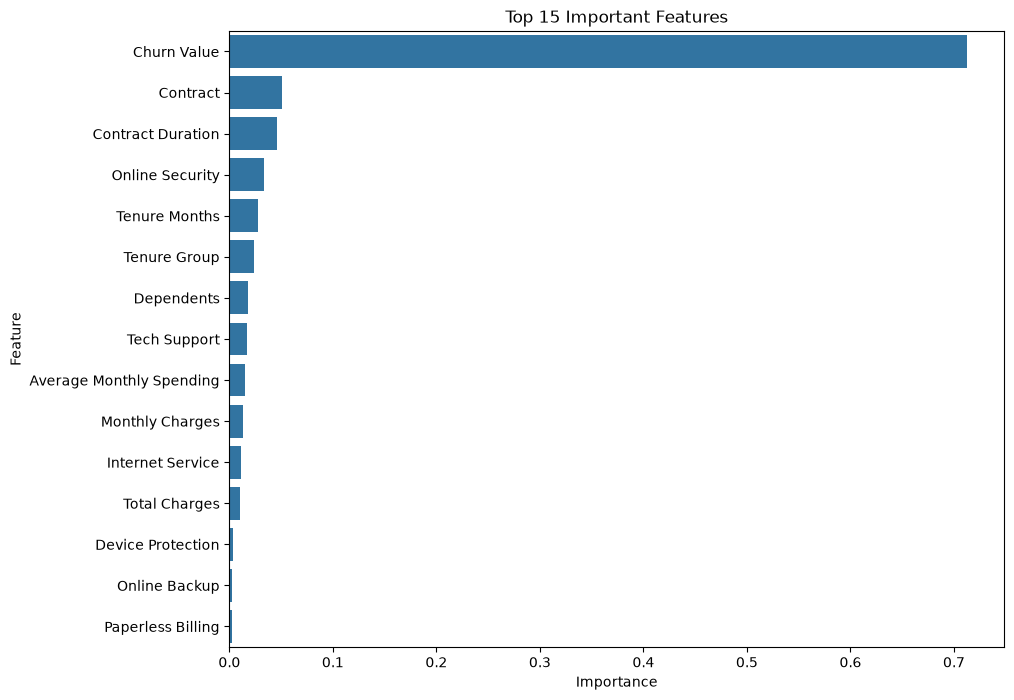

In [22]:
# Plot Feature Importance

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig(
    os.path.join(
        SAVE_PATH,
        "Feature_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Permutation Importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

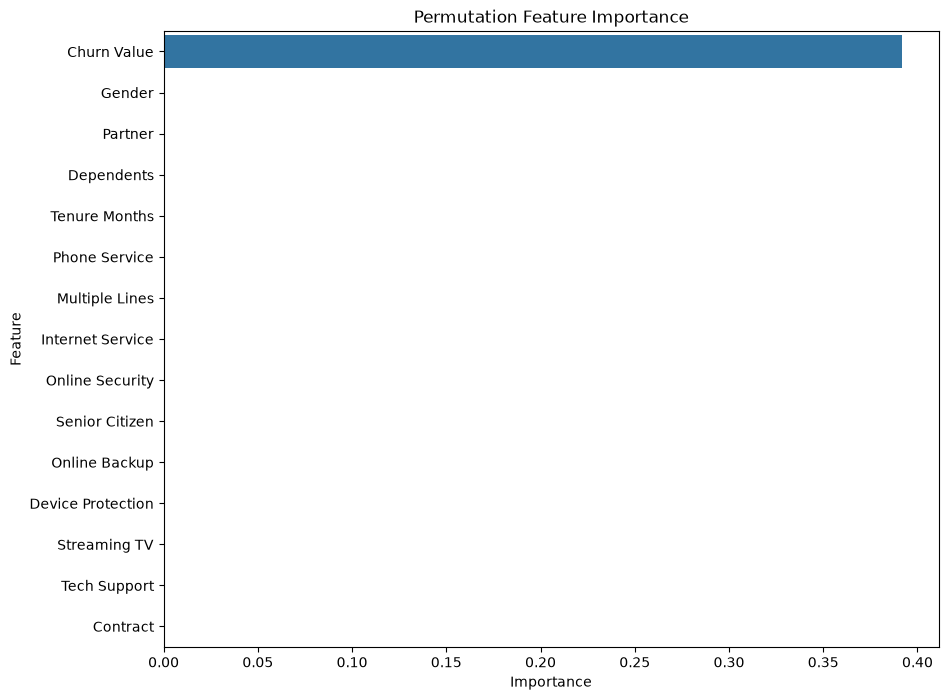

In [24]:
# Plot Permutation Importance

perm_df = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":perm.importances_mean

})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=perm_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.savefig(
    os.path.join(
        SAVE_PATH,
        "Permutation_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# SHAP Explainer
# Use shap.Explainer when available; fallback to TreeExplainer
explainer = None
shap_values = None
try:
    explainer = shap.Explainer(model, X_train, feature_names=X_train.columns)
    shap_values = explainer(X_test)
except Exception:
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
    except Exception as e:
        print("SHAP explainer failed:", e)
        explainer = None
        shap_values = None

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


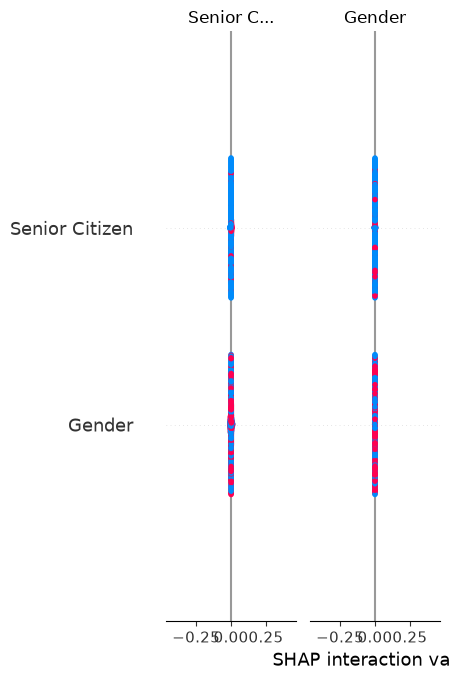

In [26]:
# SHAP Summary Plot
if shap_values is not None:
    try:
        # Newer SHAP returns an Explanation object; older returns arrays/lists
        shap.summary_plot(shap_values, X_test, show=False)
    except Exception:
        try:
            shap.summary_plot(getattr(shap_values, 'values', shap_values), X_test, show=False)
        except Exception as e:
            print("SHAP summary plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Summary.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP summary plot.")

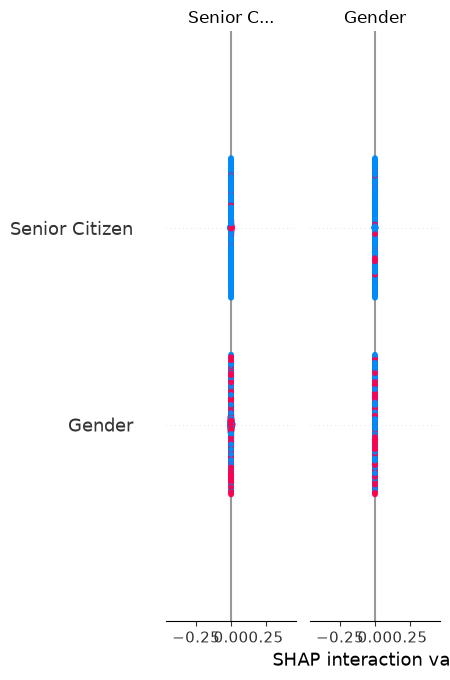

In [27]:
# SHAP Bar Plot
if shap_values is not None:
    try:
        shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    except Exception:
        try:
            shap.summary_plot(getattr(shap_values, 'values', shap_values), X_test, plot_type="bar", show=False)
        except Exception as e:
            print("SHAP bar plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Bar.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP bar plot.")

In [28]:
# SHAP Waterfall Plot
if shap_values is not None:
    try:
        # If shap_values is an Explanation object (newer SHAP), use its first row
        if hasattr(shap_values, 'values'):
            shap.plots.waterfall(shap_values[0], show=False)
        else:
            # Older API: shap_values may be an array or list. Try to plot the first sample.
            single = None
            if isinstance(shap_values, (list, tuple)):
                # multiclass may return a list; pick first class's first sample
                single = shap_values[0]
                if isinstance(single, (list, tuple)):
                    single = single[0]
            else:
                single = shap_values[0]
            try:
                expl = shap.Explanation(
                    values=single,
                    base_values=getattr(explainer, 'expected_value', None),
                    data=X_test.iloc[0],
                    feature_names=X_test.columns
                )
                shap.plots.waterfall(expl, show=False)
            except Exception:
                shap.plots.waterfall(single, show=False)
    except Exception as e:
        print("SHAP waterfall plot failed:", e)
    plt.savefig(
        os.path.join(
            SAVE_PATH,
            "SHAP_Waterfall.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No shap values available; skipping SHAP waterfall plot.")

SHAP waterfall plot failed: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (26, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


<Figure size 640x480 with 0 Axes>

In [29]:
# Save SHAP Values

joblib.dump(
    shap_values,
    "../models/shap_values.pkl"
)

['../models/shap_values.pkl']

In [30]:
# Top 10 Features Table

top10 = importance.head(10)

top10.to_excel(
    "../reports/top10_features.xlsx",
    index=False
)

top10

,Feature,Importance
19,Churn Value,0.713043
14,Contract,0.051091
25,Contract Duration,0.045646
8,Online Security,0.033152
4,Tenure Months,0.027195
20,Tenure Group,0.023746
3,Dependents,0.018347
11,Tech Support,0.017302
23,Average Monthly Spending,0.014866
17,Monthly Charges,0.013277


In [31]:
# Observations

# The interpretation techniques identified the most influential features affecting customer churn.

# The feature importance and SHAP analysis help explain model predictions and provide transparency for business stakeholders.

# These insights can guide telecom companies in developing targeted customer retention strategies.